<a href="https://colab.research.google.com/github/Juansfv22/Fake-News-NLP/blob/main/Fake_News_with_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de Fake News con PLN

Este proyecto consta de el uso de algunas técnicas de Procesamiento de Lenguaje Natural para entrenar distintos modelos mediante aprendizaje supervisado, con el fin de identificar noticias falsas en un corpus de 5200 noticias. Este corpus fue construido a partir de 2600 noticias verdaderas (procedentes de periódicos confiables) y 2600 noticias falsas (procedentes de sitios sin credibilidad). Para cada tipo, 100 de sus noticias fueron obtenidas mediante web scraping, y el resto mediante unos datasets.

La primera sección de este notebook corresponde a esa extracción del corpus. Para ir directamente al proceso de entrenamiento se puede avanzar a la sección 2 que ya cuenta con acceso al corpus creado y listo para ser usado.

## 1. Creación corpus
---

In [ ]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np

In [ ]:
# Montar Google Drive para acceder a los archivos
from google.colab import drive
drive.mount('/content/drive/')

# Y acceder a las variables de entorno
from google.colab import userdata

Mounted at /content/drive/


Se usaron los siguientes 3 datasets para la extracción de las primeras 5000 noticias: los primeros 2 para las 2500 verdaderas y el último para las 2500 falsas. Para ejecutar estos pasos es necesario descargar estos datasets en formato csv y guardar su dirección en variables de entorno como se nombran más adelante en cada uno.

*   [Spanish News](https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news)
*   [Spanish Fake News Dataset](https://zenodo.org/records/15592391)

*   [Noticias Falsas en Español](https://www.kaggle.com/datasets/arseniitretiakov/noticias-falsas-en-espaol)

### Spanish News Dataset

---

**Descripción del Contenido**

El conjunto de datos incluye artículos de fuentes de noticias españolas confiables que abarcan diferentes categorías, como política, economía, deportes, cultura, tecnología y más.  


**Descripción de Campos**  

| Nombre de columna  | Descripción |
|--------------------|-------------|
| `language`         | Idioma de origen |
| `category`         | Categoría tematíca (ej. fashion, politics, motor, sport...) |
| `newspaper`        | Nombre del periódico que lo publico |
| `hash`             | ID - Hash |
| `text`             | Contenido del artículo |


---

In [ ]:
# Cargar el dataset de noticias reales en español desde Google Drive
pd_real_news_es = pd.read_csv(userdata.get("ruta_real_news"))
pd_real_news_es.sample(5)

,language,category,newspaper,hash,text
10089,es,economy,diario_cordoba,af63f0c29461577c06bc0d3e9f6d7e8bd5a73437,La Seguridad Social empezó el año con 37.183 a...
6531,es,politics,el_periodico,a8ff65ede87362eeea163064247bf8dc71253947,Entre ataques al PP por su llamada al voto úti...
7377,es,military,defensa,164f61c334d494d537ffb9d0e1f6d69e8041bb8b,El salón policial MILIPOL nos ha permitido con...
9482,es,economy,europapress,82dc119e214e6c9d1b2e02026550cb53fa9dffc5,"MADRID, 12 Feb. (EUROPA PRESS) - SSE Renewa..."
9765,es,economy,libertad_digital,1d7662777b9cbf76ea16d0a5ceee0b2cd4c37f88,e-Residency es una identidad digital emitida p...


In [ ]:
# Lista de periódicos considerados confiables
real_newspaper = [
    'el_pais',
    'la_vanguardia',
    'el_periodico',
    'el_periodico_de_aragon',
    'el_periodico_de_espana',
    'rtve',
    'europapress',
    'bbc_news',
    'wired',
    'el_economista',
    'diario_de_sevilla',
    'diario_de_leon',
    'diario_cordoba'
]

# Filtrar el DataFrame para incluir solo noticias de los periódicos confiables
df_real_news_es = pd_real_news_es[pd_real_news_es["newspaper"].isin(real_newspaper)]
# Seleccionar solo la columna 'text' y crear una copia
df_real_news_es = df_real_news_es[["text"]].copy()
df_real_news_es.sample(5)

,text
10049,Las haciendas forales vascas recaudaron el año...
1069,La compañía Telespazio Ibérica se acaba de adj...
7650,"Fuente de la imagen, APEl papiro fue escrito e..."
6714,El edil de Vox en el Ayuntamiento de Badajoz J...
10093,"El ministro de Agricultura español, Luis Plana..."


### Noticias Falsas en Español Dataset

---

**Descripción del Contenido**

Colección que recopila información acerca de noticias falsas y verdaderas para clasificación.

Se consume el apartado del dataset que contiene las noticias verdaderas:
- `onlytrue1000.csv`


**Descripción de Campos**  

| Nombre de columna  | Descripción |
|--------------------|-------------|
| `text`         | Contenido del artículo en español |

---

In [ ]:
# Cargar este otro dataset de noticias verdaderas desde Google Drive
df_true_news_es = pd.read_csv(userdata.get("ruta_true_news"))
df_true_news_es.sample(5)

,text
550,La académica y activista Stella Nyanzi lleva o...
145,"La vicesecretaria general del PSOE, Adriana L..."
960,Cuando vender discos dejó de ser la pauta con...
791,Quim Torra ha vuelto a colocar la pancarta con...
7,El nuevo plan migratorio del presidente parec...


### Spanish Fake News Dataset

---

**Descripción**

Colección estructurada y anotada de **noticias falsas en español (castellano)**, recopiladas y procesadas para la **investigación académica sobre desinformación**.

Incluye muestras de información falsa en distintos formatos:  

- Artículos y titulares de noticias  
- Publicaciones en Twitter, Facebook, Instagram y Telegram  
- Subtítulos de videos en YouTube  
- Transcripciones de mensajes de texto y voz en WhatsApp  
- Fragmentos transcritos de audio/video con afirmaciones falsas  
- Documentos gubernamentales falsificados  
- Subtítulos de fotos y memes  
- Texto extraído de imágenes mediante OCR  

Solo se consideraron textos en **español (castellano)**, excluyendo variantes regionales (ej. catalán, euskera, gallego) para mantener la consistencia.  

**Descripción de Campos**

| Nombre de columna  | Descripción |
|--------------------|-------------|
| `Topic`            | Categoría temática (ej. *Política*, *Salud*, *COVID-19*, *Crimen*). Normalizada y traducida al inglés. |
| `Link source`      | URL de la noticia original, artículo de verificación o fuente de la afirmación. Se eliminaron enlaces inválidos. |
| `Media`            | Plataforma o medio donde apareció la noticia falsa (ej. Facebook, YouTube, WhatsApp). Normalizado. |
| `Date`             | Fecha de publicación o verificación en formato `YYYY-MM-DD`. |
| `Author`           | (Opcional) Autor de la noticia o fuente, si está disponible. Puede estar vacío. |
| `Headlines`        | Titular o resumen de la noticia con la información falsa. |
| `Fake statement`   | Cita textual de la afirmación falsa tal como aparece en el artículo de verificación. |

**Fuentes**

Los datos provienen de iniciativas de **verificación de hechos**:  

- [Maldito Bulo](https://maldita.es/malditobulo/)  
- [Newtral](https://www.newtral.es/zona-verificacion/fakes/)  
- [AFP Factual](https://factual.afp.com/)  

Estas organizaciones publican artículos detallados que suelen incluir:  
- Contexto del evento  
- Citas o enlaces a afirmaciones falsas  
- Análisis de por qué la información es falsa  
- Datos verificados o correcciones



---

In [ ]:
# Cargar el dataset de noticias falsas en español desde Google Drive
pd_fake_news_es = pd.read_csv(userdata.get("ruta_fake_news"))
pd_fake_news_es.sample(5)

,Topic,Link source,Media,Date,author,Headlines,Fake statement
1812,Science,NaN,WhatsApp,NaN,NaN,NaN,"Mi nombre es Alejandro, soy Cardiólogo y socor..."
913,Celebrities,https://www.minuto30.com/fotos-irreconocible-a...,minuto30,2018-06-14,Gisela Saldarriaga Molina,FOTOS: ¡Irreconocible! así lucía la “La Bruja ...,Unas fotografías de Doña Clotilde o bien conoc...
2451,Religion,NaN,NaN,NaN,NaN,NaN,Érase una vez en Valencia en estado de Alarma ...
1449,Politics,https://twitter.com/Alvisepf/status/1175489571...,Twitter,2019-09-21,Alvisepf,NaN,Se llama Carmela Silva. No la conoceréis porqu...
2247,COVID-19,NaN,NaN,NaN,NaN,NaN,Respuesta pregunta 7: Con la información que p...


In [ ]:
# Copiar la columna 'Fake statement' a una nueva columna llamada 'text'
pd_fake_news_es["text"] = pd_fake_news_es["Fake statement"].copy()
# Seleccionar solo la columna 'text' y crear una copia
df_fake_news_es = pd_fake_news_es[["text"]].copy()
df_fake_news_es.sample(5)

,text
1666,"Paso 1. No ""te niegues"" a la vacuna o sino ser..."
1584,ESTÁN LLEGANDO NOTICIAS DE QUE EN LA NUIT (baj...
1194,Cataluña saca a la calle robots de combate.
1090,"Geoingenieria con el uso de chemtrails, estela..."
923,El Ayuntamiento de Londres se dispone a prohib...


### Web Scraping

Ahora, en esta parte se obtienen las 200 noticias restantes con técnicas de extracción automatizada en la web.

---

In [ ]:
# Instalar dependencias para Selenium (Chrome y Chromedriver)
%%shell

apt-get update
apt-get install -y wget unzip xvfb libxi6 libgconf-2-4

# Escoge la versión estable de Chrome
wget https://storage.googleapis.com/chrome-for-testing-public/131.0.6778.85/linux64/chrome-linux64.zip
wget https://storage.googleapis.com/chrome-for-testing-public/131.0.6778.85/linux64/chromedriver-linux64.zip

# Descomprimir Chrome
unzip chrome-linux64.zip
mv chrome-linux64 /usr/local/chrome

# Descomprimir Chromedriver
unzip chromedriver-linux64.zip
mv chromeddriver-linux64/chromedriver /usr/local/bin/chromedriver
chmod +x /usr/local/bin/chromedriver

# Instalar selenium
pip install selenium

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,802 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,287 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 http://security.ubu

In [ ]:
# Importar módulos necesarios de Selenium
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium import webdriver
import time

# Definir las rutas de Chrome y Chromedriver
chrome_path = "/usr/local/chrome/chrome"
driver_path = "/usr/local/bin/chromedriver"

# Configurar las opciones de Chrome para ejecutar en modo headless (sin interfaz gráfica)
options = Options()
options.binary_location = chrome_path

options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

# Configurar el servicio de Chromedriver
service = Service(driver_path)
# Inicializar el navegador Chrome con las opciones y el servicio configurados
driver = webdriver.Chrome(service=service, options=options)

In [ ]:
# Navegar a la página principal de BBC Mundo
driver.get("https://www.bbc.com/mundo")

# Encontrar el enlace a la sección "América Latina" y obtener su URL
latin_america_link = driver.find_element(By.XPATH, '//a[text()="América Latina"]')
latin_america_url = latin_america_link.get_attribute("href")
# Hacer clic en el enlace para ir a la sección de América Latina
latin_america_link.click()

# Lista para almacenar las noticias reales
real_news = []
i = 1
# Bucle para scrapear hasta 100 noticias
while len(real_news) <= 100:
    # Encontrar todos los enlaces de artículos en la página actual
    article_links = driver.find_elements(By.XPATH, '//div[@class="promo-text"]/h2/a')
    # Obtener las URLs de los artículos
    article_urls = [link.get_attribute("href") for link in article_links]

    # Iterar sobre las URLs de los artículos
    for link in article_urls:
        # Navegar a la página de cada artículo
        driver.get(link)

        # Encontrar todos los párrafos del artículo (excluyendo los últimos 4 que suelen ser metadatos)
        paragraphs  = driver.find_elements(By.XPATH, '//main/div/p')[:-4]
        # Unir los textos de los párrafos en una sola cadena
        article_text = " ".join([p.text for p in paragraphs])

        # Agregar la URL y el texto del artículo a la lista de noticias reales
        real_news.append({
            "url": link,
            "text": article_text
        })
    i+=1
    # Navegar a la siguiente página de la sección América Latina
    driver.get(latin_america_url + f"?page={i}")

# Cerrar el navegador
driver.quit()

In [ ]:
# Crear un DataFrame de pandas a partir de la lista de noticias reales scrapeadas
df_scrapping_real_news = pd.DataFrame(real_news)
df_scrapping_real_news.sample(5)

,url,text
87,https://www.bbc.com/mundo/articles/clyv1rn0j88o,El frío y la humedad eran extremos. Alrededor ...
91,https://www.bbc.com/mundo/articles/ce3j4qe0zzvo,El Tribunal Supremo de Brasil ordenó este lune...
47,https://www.bbc.com/mundo/articles/cwy0q4nq1wqo,Un cuadro robado por los nazis a un comerciant...
57,https://www.bbc.com/mundo/articles/cdj2mj8nkymo,El vocalista y director de la agrupación Enigm...
45,https://www.bbc.com/mundo/articles/c201gwwpd21o,"""Todos llenos de alegría… en esta fecha natal,..."


In [ ]:
# Seleccionar solo la columna 'text' y crear una copia del DataFrame scrapeado
df_scrapping_real_news = df_scrapping_real_news[["text"]].copy()
# Tomar una muestra aleatoria de 100 filas del DataFrame
df_scrapping_real_news = df_scrapping_real_news.sample(n=100, random_state=42)
df_scrapping_real_news.sample(5)

,text
56,"La noche del 31 de mayo de 1961, el dictador R..."
61,"""Aspirante a dictador. En Estados Unidos, no"",..."
25,La idea le vino a René Higuita mientras filmab...
80,Un precandidato presidencial que recibe varios...
70,"Cualquier terreno, edificación o cuerpo de agu..."


In [ ]:
# Definir las rutas de Chrome y Chromedriver (se repite la configuración)
chrome_path = "/usr/local/chrome/chrome"
driver_path = "/usr/local/bin/chromedriver"

# Configurar las opciones de Chrome para ejecutar en modo headless (sin interfaz gráfica)
options = Options()
options.binary_location = chrome_path

options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

# Configurar el servicio de Chromedriver
service = Service(driver_path)
# Inicializar el navegador Chrome con las opciones y el servicio configurados
driver = webdriver.Chrome(service=service, options=options)

In [ ]:
# Navegar a la página de Mediterráneo Digital (sección Internacional) para scrapear noticias falsas
driver.get("https://www.mediterraneodigital.com/espana/internacional")

# Lista para almacenar las URLs de los artículos
articles_urls = []

# Bucle para scrapear hasta 100 URLs de artículos
while len(articles_urls) <= 100:
    # Encontrar todos los enlaces de artículos en la página actual
    articles_links = driver.find_elements(By.XPATH, '//div[contains(@class, "article-image")]/div/a')
    # Obtener las URLs de los artículos
    articles_urls = [link.get_attribute("href") for link in articles_links]

    # Encontrar y hacer clic en el botón "Cargar más" (infinity scroll)
    next_button = driver.find_element(By.ID, 'infinity-next')
    next_button.click()


# Lista para almacenar las noticias falsas
fake_news = []

# Iterar sobre las URLs de los artículos scrapeados
for link in articles_urls:
    # Navegar a la página de cada artículo
    driver.get(link)

    # Encontrar todos los párrafos del artículo
    paragraphs  = driver.find_elements(By.XPATH, '//section[contains(@class, "article-content")]/p')
    # Unir los textos de los párrafos en una sola cadena
    article_text = " ".join([p.text for p in paragraphs])

    # Agregar la URL y el texto del artículo a la lista de noticias falsas
    fake_news.append({
        "url": link,
        "text": article_text
    })

# Cerrar el navegador
driver.quit()

In [ ]:
# Crear un DataFrame de pandas a partir de la lista de noticias falsas scrapeadas
df_scrapping_fake_news = pd.DataFrame(fake_news)
df_scrapping_fake_news.sample(5)

,url,text
54,https://www.mediterraneodigital.com/espana/int...,"Por primera vez en la historia, el partido de ..."
38,https://www.mediterraneodigital.com/espana/int...,"Recientemente, dos marines estadounidenses fue..."
98,https://www.mediterraneodigital.com/espana/int...,El debate sobre el Covid vuelve a estar el pun...
13,https://www.mediterraneodigital.com/espana/int...,Mientras los centros sanitarios de España se «...
90,https://www.mediterraneodigital.com/espana/int...,Rusia no dejará sin respuesta el ingreso de Fi...


In [ ]:
# Seleccionar solo la columna 'text' y crear una copia del DataFrame scrapeado
df_scrapping_fake_news = df_scrapping_fake_news[["text"]].copy()
# Tomar una muestra aleatoria de 100 filas del DataFrame
df_scrapping_fake_news = df_scrapping_fake_news.sample(n=100, random_state=42)
df_scrapping_fake_news.sample(5)

,text
61,"Saltanat Nukenov, durante una discusión con su..."
2,El Gobierno socialista de Pedro Sánchez lo ha ...
96,"Un fuerte terremoto de magnitud 7,8 sacudió la..."
57,"En la Asamblea General de las Naciones Unidas,..."
91,La Corte Penal Internacional (CPI) emitió este...


### Guardar datos
---

In [ ]:
# Importar la librería os para interactuar con el sistema operativo
import os

In [ ]:
# Definir una función para guardar un array de textos como archivos .txt
def bulk_upload(array, dir, name):

    # Crear el directorio si no existe
    if not os.path.exists(dir):
        os.makedirs(dir)

    # Iterar sobre el array de textos
    for i in range(len(array)):
        # Generar los nombres de los archivos
        file_name = f"{name}-{i + 1:04d}.txt"
        # Construir la ruta completa del archivo
        file_path = os.path.join(dir, file_name)

        # Si el archivo ya existe, saltar a la siguiente iteración (para evitar sobreescribir)
        if os.path.exists(file_path):
            continue

        # Abrir el archivo en modo escritura con codificación utf-8
        with open(file_path, "w", encoding="utf-8") as f:
            # Escribir el texto en el archivo
            f.write(array[i])

In [ ]:
# Concatenar los DataFrames de noticias reales de los datasets
df_real_news = pd.concat([df_real_news_es, df_true_news_es])
# Tomar una muestra aleatoria de 2500 noticias reales
df_sample_real_news = df_real_news.sample(n=2500, random_state=42)

# Concatenar la muestra de noticias reales con las noticias reales scrapeadas
df_real_news_with_scrapping = pd.concat([df_sample_real_news, df_scrapping_real_news])

df_real_news_with_scrapping.sample(5)

,text
3442,"En 1999, Emilio Alzamora ganó el mundial de mo..."
928,La Amazonia brasileña perdió 9.762 kilómetros...
7756,El Papa celebrará misa junta al patriarca ecum...
3299,comentarios 41Gráfica a escala de la aproximac...
717,Los delitos sexuales tienen una tendencia crec...


In [ ]:
# Copiar el DataFrame de noticias falsas
df_fake_news = df_fake_news_es.copy()
# Tomar una muestra aleatoria de 2500 noticias falsas
df_sample_fake_news = df_fake_news.sample(n=2500, random_state=40)

# Concatenar la muestra de noticias falsas con las noticias falsas scrapeadas
df_sample_fake_news_with_scrapping = pd.concat([df_sample_fake_news, df_scrapping_fake_news])
df_sample_fake_news_with_scrapping.sample(5)

,text
1184,"Antiindependentista y de ""centro"": así es el P..."
969,"La ministra de Sanidad, María Luisa Carcedo, p..."
1091,El 95% de plástico que contamina los océanos p...
1788,JUEVES 30 DE JULIO Se pasarán a fase 1 las sig...
1478,"Durante el mandato d Manuela Carmena, se han p..."


In [ ]:
# Definir la ruta para guardar las noticias reales
real_news_path = userdata.get("save_real_news")

# Llamar a la función bulk_upload para guardar las noticias reales en archivos .txt
bulk_upload(list(df_real_news_with_scrapping["text"]), real_news_path, "real-news")

In [ ]:
# Definir la ruta para guardar las noticias falsas
fake_news_path = userdata.get("save_fake_news")

# Llamar a la función bulk_upload para guardar las noticias falsas en archivos .txt
bulk_upload(list(df_sample_fake_news_with_scrapping["text"]), fake_news_path, "fake-news")

## 2. Cargar datos

En este punto se comienza a trabajar sobre el corpus listo y de acceso directo.

In [ ]:
# Importar librerías necesarias
import os
import gdown
import zipfile
import pandas as pd
import numpy as np

# Archivo de origen que contiene el corpus
DATASET_ZIP = "Datos.zip"
FILE_ID = "1rKZJZURWpHh-Y3RMadRqjoB38M0LnYiJ"

# Nombre de la carpeta local en Colab donde se descargará todo
DATASET_DIR = "Datos"

# Descargar el archivo ZIP
if not os.path.exists(DATASET_DIR):
    url = f'https://google.com/{FILE_ID}'
    gdown.download(output=DATASET_ZIP, id=FILE_ID, quiet=False)

    # Descomprimir el archivo
    print("Extrayendo archivos...")
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
        zip_ref.extractall(".") # Esto creará la carpeta 'Datos'

    # Borrar el zip para ahorrar espacio en disco
    os.remove(DATASET_ZIP)

In [ ]:
# Definir las rutas a las carpetas que contienen los archivos de noticias
folder_paths = {
    "1": os.path.join(DATASET_DIR, "Verdad"), # '1' representa noticias verdaderas
    "0": os.path.join(DATASET_DIR, "Falso") # '0' representa noticias falsas
}

# Lista para almacenar los datos del corpus
data = []
# Iterar sobre las carpetas y sus etiquetas
for label, folder in folder_paths.items():

    #Verificar la existencia de la carpeta de datos
    if not os.path.exists(folder):
        print(f"No se encontró la carpeta {folder}")
        continue

    # Iterar sobre los archivos en cada carpeta
    for filename in os.listdir(folder):
        # Construir la ruta completa del archivo
        file_path = os.path.join(folder, filename)

        # Verificar si es un archivo y termina con .txt
        if not os.path.isfile(file_path) or not filename.endswith(".txt"):
            continue

        # Abrir y leer el contenido del archivo
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
            # Agregar el texto y su etiqueta a la lista de datos
            data.append({"text": text, "type": label})

# Crear un DataFrame de pandas a partir de la lista de datos
df_corpus = pd.DataFrame(data)
df_corpus.sample(5)

,text,type
3228,la vicepresidenta del Gobierno Carmen Calvo se...,0
1426,La Generalitat de Catalunya ha alertado hoy d...,1
2549,Para establecer futuras bases en la Luna y en ...,1
763,La economía de Taiwán ofrece oportunidades de ...,1
4383,"Por favor, no envíe buenos deseos / mensajes d...",0


In [ ]:
# Calcular el número de palabras en cada texto del corpus
word_counts = np.array(df_corpus["text"].apply(lambda x: len(x.split())))

# Calcular varias métricas descriptivas sobre el conteo de palabras
metrics = {
    'Mean': np.mean(word_counts), # Media
    'Std': np.std(word_counts),   # Desviación estándar
    'Min': np.min(word_counts),   # Mínimo
    'Max': np.max(word_counts),   # Máximo
    'Sum': np.sum(word_counts),   # Suma total
    'Quartiles': np.percentile(word_counts, [25, 50, 75]).tolist() # Cuartiles (25%, 50%, 75%)
}

# Imprimir las métricas calculadas
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Mean: 270.78326923076924
Std: 382.1658446740969
Min: 0
Max: 4558
Sum: 1408073
Quartiles: [35.0, 53.0, 415.0]


## 3. Preprocesamiento

---

In [ ]:
# Importar módulos para expresiones regulares y normalización de texto
from re import compile
import unicodedata

In [ ]:
# Compilar expresiones regulares para limpieza de texto
RE_DIGITS = compile(r'\d+') # Encuentra dígitos
RE_URL_MENTION = compile(r'http\S+|www\S+|@\S+') # Encuentra URLs y menciones de usuario
RE_HTML_TAGS = compile(r'<.*?>') # Encuentra etiquetas HTML
RE_PUNCT = compile(r'[^\w\s]') # Encuentra signos de puntuación
RE_SPACES = compile(r'\s+') # Encuentra múltiples espacios

# Definir la función de limpieza de texto
def clean_text(text):

    # Verificar si la entrada es una cadena de texto
    if not isinstance(text, str):
        return ""

    # Pasar a minúsculas
    text = text.lower()

    # Normalizar y quitar acentos
    # unicodedata.normalize('NFD', text) descompone los caracteres con acento
    # unicodedata.category(c) != 'Mn' filtra los caracteres de marca diacrítica
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

    # Eliminar números
    text = RE_DIGITS.sub(' ', text)

    # Eliminar URLs y menciones (@usuario)
    text = RE_URL_MENTION.sub(' ', text)

    # Sustituir saltos de línea por espacio
    text = text.replace("\n", " ").replace("\r", " ")

    # Eliminar etiquetas HTML
    text = RE_HTML_TAGS.sub(' ', text)

    # Eliminar signos de puntuación
    text = RE_PUNCT.sub(' ', text)

    # Quitar múltiples espacios y espacios al inicio/fin
    text = RE_SPACES.sub(' ', text).strip()

    return text

In [ ]:
# Mezclar aleatoriamente el DataFrame del corpus y resetear el índice
df = df_corpus.sample(frac=1, random_state=42).reset_index(drop=True)
# Aplicar la función clean_text a la columna 'text'
df["text"] = df["text"].apply(clean_text)
# Mostrar las primeras 5 filas del DataFrame limpio
df.head()

,text,type
0,boletin informativo en audio que recoge la act...,1
1,madrid feb europa press el ibex cerro la seman...,1
2,alemania suspende test pcr que se sabe son cie...,0
3,se cumplen anos del extraordinario descubrimie...,1
4,el origen del vih fue un experimento a manos d...,0


## 4. Extracción de caracteristicas

---

In [ ]:
# Importar módulos necesarios para procesamiento de lenguaje natural
from nltk.corpus import stopwords
from nltk.stem.snowball import SpanishStemmer
import nltk

# Descargar el paquete de stopwords de NLTK
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Obtener la lista de stopwords en español
stopwords_es = stopwords.words("spanish")
# Inicializar el stemmer para español
stemmer = SpanishStemmer()

# Aplicar eliminación de stopwords a la columna 'text' y crear una nueva columna 'text_stopwords'
df["text_stopwords"] = df["text"].apply(lambda x: ' '.join([word for word in x.split() if word not in stopwords_es]))
# Aplicar stemming a la columna 'text' y crear una nueva columna 'text_stemming'
df["text_stemming"] = df["text"].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))
# Aplicar stemming a la columna 'text_stopwords' y crear una nueva columna 'text_stopwords_stemming'
df["text_stopwords_stemming"] = df["text_stopwords"].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))

df.sample(5)

,text,type,text_stopwords,text_stemming,text_stopwords_stemming
1035,la policia nacional de ceuta ha detenido en la...,1,policia nacional ceuta detenido ultimas horas ...,la polici nacional de ceut ha deten en las ult...,polici nacional ceut deten ultim hor seis pers...
2207,las mascarillas han matado a dos ninos en alem...,0,mascarillas matado dos ninos alemania,las mascarill han mat a dos nin en alemani,mascarill mat dos nin alemani
2368,el presidente de guatemala bernardo arevalo as...,1,presidente guatemala bernardo arevalo asumio p...,el president de guatemal bernard areval asumi ...,president guatemal bernard areval asumi pod en...
3363,un total de andaluces siguen en la lista de es...,1,total andaluces siguen lista espera recibir ay...,un total de andaluc sig en la list de esper pa...,total andaluc sig list esper recib ayud presta...
3954,es responsable de recursos humanos y gerente d...,0,responsable recursos humanos gerente podemos i...,es respons de recurs human y gerent de pod est...,respons recurs human gerent pod implic estaf a...


## 5. Ponderación de las caracteristicas

---

In [ ]:
# Importar las clases para vectorización de texto (CountVectorizer y TfidfVectorizer)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
# Definir un diccionario con los vectorizadores a utilizar
vectorizers_feat = {
    "TO": CountVectorizer(ngram_range=(1,2), min_df=3), # CountVectorizer: cuenta la frecuencia de palabras y bigramas, ignora términos con frecuencia < 3
    "TF-IDF": TfidfVectorizer(ngram_range=(1,2), min_df=3) # TfidfVectorizer: calcula la frecuencia inversa del documento, considera palabras y bigramas, ignora términos con frecuencia < 3
}

# Definir un diccionario con los diferentes conjuntos de datos de texto procesado
datasets = {
    "raw": df["text"], # Texto original limpio
    "stopwords": df["text_stopwords"], # Texto con stopwords eliminadas
    "stemming": df["text_stemming"], # Texto con stemming aplicado
    "stop_stem": df["text_stopwords_stemming"] # Texto con stopwords eliminadas y stemming aplicado
}

## 6. Tecnicas de aprendizaje utilizadas

---

In [ ]:
# Importar las clases de modelos de aprendizaje automático y herramientas de evaluación
from sklearn.linear_model import LogisticRegression # Regresión Logística
from sklearn.tree import DecisionTreeClassifier # Árbol de Decisión
from sklearn.neighbors import KNeighborsClassifier # K-Vecinos Más Cercanos
from sklearn.svm import SVC # Máquina de Vectores de Soporte
from sklearn.model_selection import train_test_split, cross_validate # División de datos y validación cruzada

In [ ]:
# Lista para almacenar los resultados de la evaluación de los modelos
results = []

# Iterar sobre los diferentes conjuntos de datos
for name_ds, corpus in datasets.items():
    # Iterar sobre los diferentes vectorizadores
    for name_vec, vectorizer in vectorizers_feat.items():
        # Transformar el corpus de texto en una matriz de características
        X = vectorizer.fit_transform(corpus)
        # Definir las etiquetas (variable objetivo)
        y = df["type"]

        # Dividir los datos en conjuntos de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42 # 80% entrenamiento, 20% prueba
        )

        # Inicializar el modelo de Regresión Logística
        model = LogisticRegression(max_iter=2000)

        # Realizar validación cruzada con 10 iteraciones
        scores = cross_validate(
            model, X_train, y_train,
            cv=10,
            scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted'] # Métricas a calcular
        )

        # Almacenar los resultados
        results.append({
            "dataset": name_ds,
            "vectorizer": name_vec,
            "model": "Logistic Regression",
            "accuracy": scores['test_accuracy'].mean(),
            "precision": scores['test_precision_weighted'].mean(),
            "recall": scores['test_recall_weighted'].mean(),
            "f1": scores['test_f1_weighted'].mean()
        })

In [ ]:
# Iterar sobre los diferentes conjuntos de datos
for name_ds, corpus in datasets.items():
    # Iterar sobre los diferentes vectorizadores
    for name_vec, vectorizer in vectorizers_feat.items():
        # Transformar el corpus de texto en una matriz de características
        X = vectorizer.fit_transform(corpus)
        # Definir las etiquetas (variable objetivo)
        y = df["type"]

        # Dividir los datos en conjuntos de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, # 80% entrenamiento, 20% prueba
        )

        # Inicializar el modelo de Árbol de Decisión
        model = DecisionTreeClassifier(max_depth=15, min_samples_split=50, min_samples_leaf=50, random_state=10)

        # Realizar validación cruzada con 10 iteraciones
        scores = cross_validate(
            model, X_train, y_train,
            cv=10,
            scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted'] # Métricas a calcular
        )

        # Almacenar los resultados
        results.append({
            "dataset": name_ds,
            "vectorizer": name_vec,
            "model": "Decision Tree",
            "accuracy": scores['test_accuracy'].mean(),
            "precision": scores['test_precision_weighted'].mean(),
            "recall": scores['test_recall_weighted'].mean(),
            "f1": scores['test_f1_weighted'].mean()
        })

In [ ]:
# Iterar sobre los diferentes conjuntos de datos
for name_ds, corpus in datasets.items():
    # Iterar sobre los diferentes vectorizadores
    for name_vec, vectorizer in vectorizers_feat.items():
        # Transformar el corpus de texto en una matriz de características
        X = vectorizer.fit_transform(corpus)
        # Definir las etiquetas (variable objetivo)
        y = df["type"]

        # Dividir los datos en conjuntos de entrenamiento y prueba, manteniendo la proporción de clases (stratify)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y # 80% entrenamiento, 20% prueba
        )

        # Inicializar el modelo KNN
        model = KNeighborsClassifier(
            n_neighbors=15,
            metric='cosine',
            weights='distance',
            algorithm='brute'
        )

        # Realizar validación cruzada con 10 iteraciones
        scores = cross_validate(
            model, X_train, y_train,
            cv=10,
            scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted'], # Métricas a calcular
        )

        # Almacenar los resultados
        results.append({
            "dataset": name_ds,
            "vectorizer": name_vec,
            "model": "KNN",
            "accuracy": scores['test_accuracy'].mean(),
            "precision": scores['test_precision_weighted'].mean(),
            "recall": scores['test_recall_weighted'].mean(),
            "f1": scores['test_f1_weighted'].mean()
        })

In [ ]:
# Iterar sobre los diferentes conjuntos de datos
for name_ds, corpus in datasets.items():
    # Iterar sobre los diferentes vectorizadores
    for name_vec, vectorizer in vectorizers_feat.items():
        # Transformar el corpus de texto en una matriz de características
        X = vectorizer.fit_transform(corpus)
        # Definir las etiquetas (variable objetivo)
        y = df["type"]

        # Dividir los datos en conjuntos de entrenamiento y prueba, manteniendo la proporción de clases (stratify)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y # 80% entrenamiento, 20% prueba
        )

        # Inicializar el modelo SVC
        model = SVC()

        # Realizar validación cruzada con 10 iteraciones
        scores = cross_validate(
            model, X_train, y_train,
            cv=10,
            scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted'], # Métricas a calcular
        )

        # Almacenar los resultados
        results.append({
            "dataset": name_ds,
            "vectorizer": name_vec,
            "model": "SVC",
            "accuracy": scores['test_accuracy'].mean(),
            "precision": scores['test_precision_weighted'].mean(),
            "recall": scores['test_recall_weighted'].mean(),
            "f1": scores['test_f1_weighted'].mean()
        })

In [ ]:
# Crear un DataFrame a partir de la lista de resultados
df_results = pd.DataFrame(results)
# Mostrar el DataFrame con los resultados de la evaluación de los modelos
df_results

,dataset,vectorizer,model,accuracy,precision,recall,f1
0,raw,TO,Logistic Regression,0.846394,0.849563,0.846394,0.845994
1,raw,TF-IDF,Logistic Regression,0.812981,0.817247,0.812981,0.812242
2,stopwords,TO,Logistic Regression,0.847115,0.851229,0.847115,0.846577
3,stopwords,TF-IDF,Logistic Regression,0.845673,0.851550,0.845673,0.844944
4,stemming,TO,Logistic Regression,0.854327,0.857030,0.854327,0.854003
5,stemming,TF-IDF,Logistic Regression,0.821875,0.825591,0.821875,0.821277
6,stop_stem,TO,Logistic Regression,0.851683,0.854604,0.851683,0.851326
7,stop_stem,TF-IDF,Logistic Regression,0.844952,0.849756,0.844952,0.844342
8,raw,TO,Decision Tree,0.770192,0.772226,0.770192,0.769643
9,raw,TF-IDF,Decision Tree,0.748798,0.749821,0.748798,0.748471


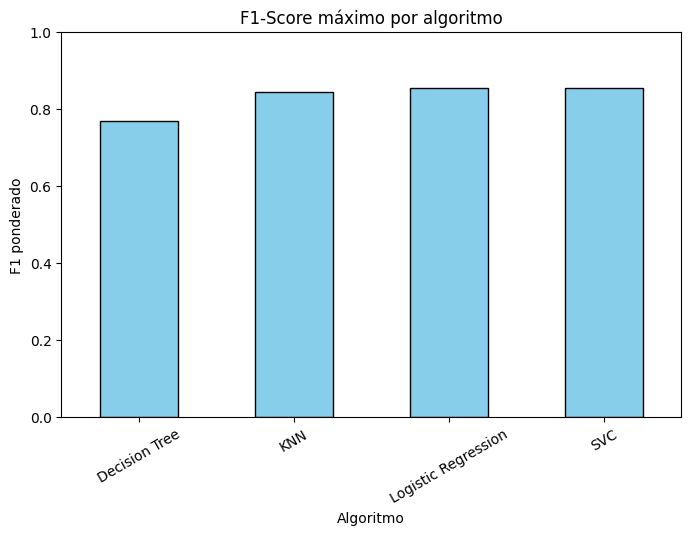

In [ ]:
# Importar la librería matplotlib para visualización
import matplotlib.pyplot as plt

# Crear una figura para el gráfico con un tamaño específico
plt.figure(figsize=(8,5))
# Agrupar los resultados por modelo y obtener el máximo F1-Score para cada uno, luego graficarlo como un gráfico de barras
df_results.groupby("model")["f1"].max().plot(kind="bar", color="skyblue", edgecolor="black")
# Establecer el título del gráfico
plt.title("F1-Score máximo por algoritmo")
# Establecer la etiqueta del eje y
plt.ylabel("F1 ponderado")
# Establecer la etiqueta del eje x
plt.xlabel("Algoritmo")
# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=30)
# Establecer los límites del eje y
plt.ylim(0,1)
# Mostrar el gráfico
plt.show()

<Figure size 1000x600 with 0 Axes>

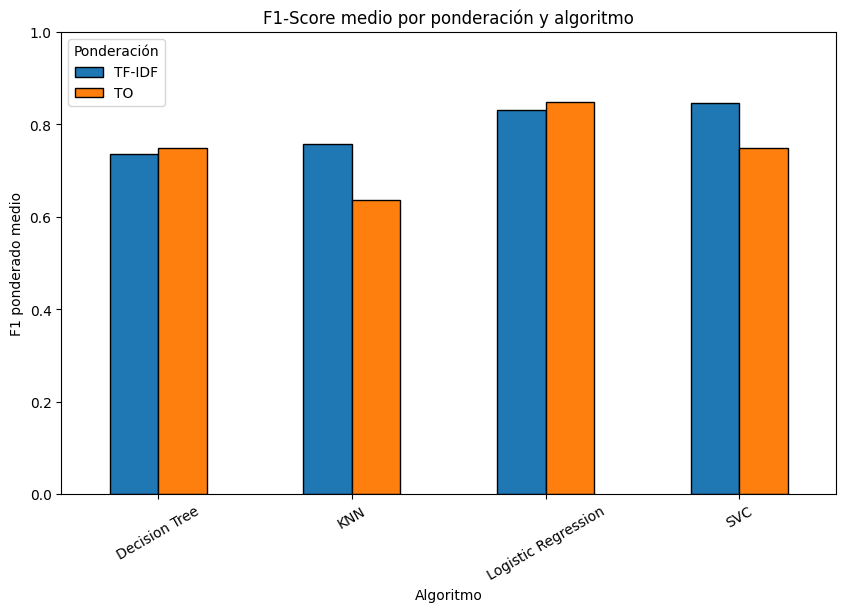

In [ ]:
# Crear una figura para el gráfico con un tamaño específico
plt.figure(figsize=(10,6))
# Agrupar los resultados por modelo y vectorizador, calcular el F1-Score medio y desagrupar por vectorizador para graficar
df_results.groupby(["model", "vectorizer"])["f1"].mean().unstack().plot(
    kind="bar", figsize=(10,6), edgecolor="black"
)
# Establecer el título del gráfico
plt.title("F1-Score medio por ponderación y algoritmo")
# Establecer la etiqueta del eje y
plt.ylabel("F1 ponderado medio")
# Establecer la etiqueta del eje x
plt.xlabel("Algoritmo")
# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=30)
# Establecer los límites del eje y
plt.ylim(0,1)
# Mostrar la leyenda con el título "Ponderación"
plt.legend(title="Ponderación")
# Mostrar el gráfico
plt.show()

<Figure size 1200x600 with 0 Axes>

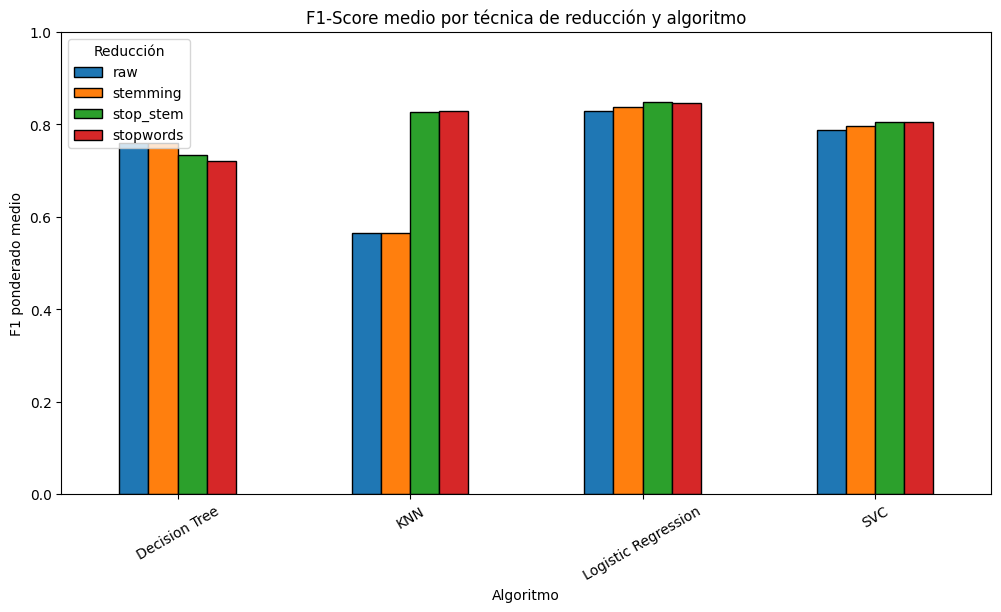

In [ ]:
# Crear una figura para el gráfico con un tamaño específico
plt.figure(figsize=(12,6))
# Agrupar los resultados por modelo y dataset, calcular el F1-Score medio y desagrupar por dataset para graficar
df_results.groupby(["model", "dataset"])["f1"].mean().unstack().plot(
    kind="bar", figsize=(12,6), edgecolor="black"
)
# Establecer el título del gráfico
plt.title("F1-Score medio por técnica de reducción y algoritmo")
# Establecer la etiqueta del eje y
plt.ylabel("F1 ponderado medio")
# Establecer la etiqueta del eje x
plt.xlabel("Algoritmo")
# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=30)
# Establecer los límites del eje y
plt.ylim(0,1)
# Mostrar la leyenda con el título "Reducción"
plt.legend(title="Reducción")
# Mostrar el gráfico
plt.show()